<a href="https://colab.research.google.com/github/maithakh/genai/blob/main/LlamaParse_project_cohort10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

|Year Ended December 31|2023|2024|
|---|---|---|
|Net cash provided by (used in) operating activities|84,946|115,877|
|Purchases of property and equipment, net of proceeds from sales and incentives|(48,133)|(77,658)|
|Free cash flow|36,813|38,219|
|Net cash provided by (used in) investing activities|(49,833)|(94,342)|
|Net cash provided by (used in) financing activities|(15,879)|(11,812)|

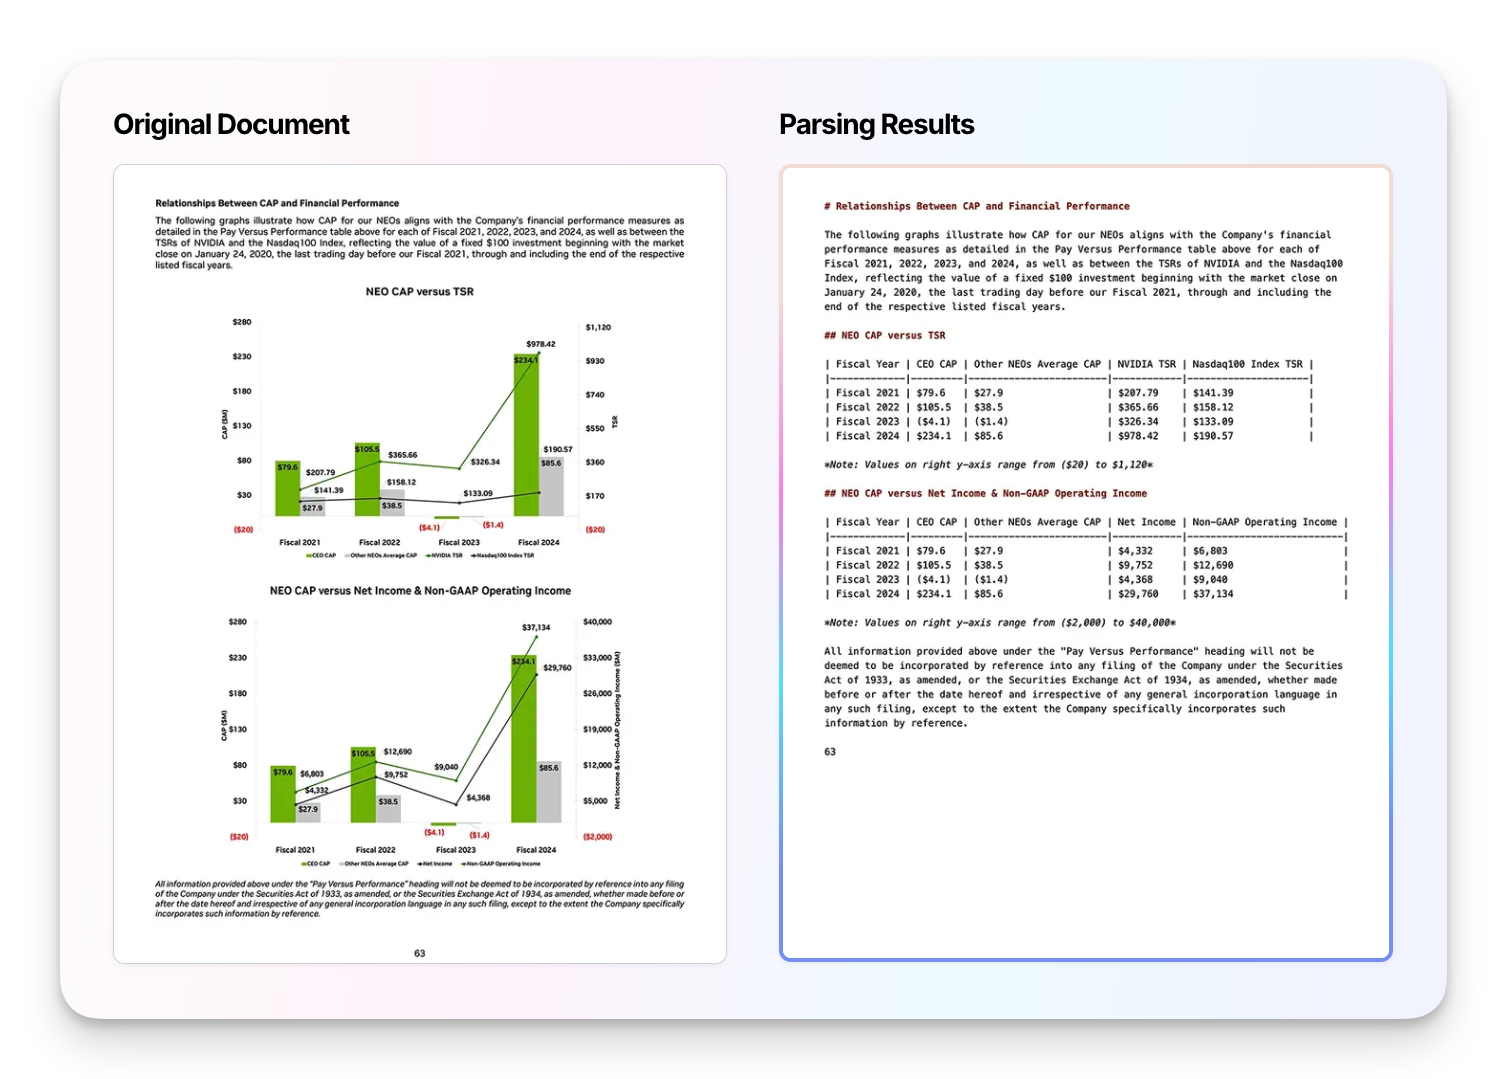

In [1]:
%pip install llama-parse llama-index


In [2]:
!wget "https://s2.q4cdn.com/470004039/files/doc_financials/2021/q4/_10-K-2021-(As-Filed).pdf" -O apple_10k.pdf


--2026-06-13 13:32:34--  https://s2.q4cdn.com/470004039/files/doc_financials/2021/q4/_10-K-2021-(As-Filed).pdf
Resolving s2.q4cdn.com (s2.q4cdn.com)... 68.70.205.1, 68.70.205.3, 68.70.205.2, ...
Connecting to s2.q4cdn.com (s2.q4cdn.com)|68.70.205.1|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 789896 (771K) [application/pdf]
Saving to: ‘apple_10k.pdf’

apple_10k.pdf       100%[===================>] 771.38K  --.-KB/s    in 0.06s   

2026-06-13 13:32:35 (12.2 MB/s) - ‘apple_10k.pdf’ saved [789896/789896]



In [4]:
import os
from google.colab import userdata
os.environ["LLAMA_CLOUD_API_KEY"] = userdata.get('llama')


In [5]:
import nest_asyncio

nest_asyncio.apply()

In [6]:
from llama_parse import LlamaParse

document = LlamaParse(result_type="markdown").load_data("/content/apple_10k.pdf")

/tmp/ipykernel_547/249190844.py:1: DeprecationWarning: The 'llama-parse' package is deprecated and will no longer receive updates. Please migrate to the new unified SDK. See https://developers.llamaindex.ai/python/cloud/llamaparse/getting_started/ and https://github.com/run-llama/llama-cloud-py/blob/main/README.md for migration instructions.
  from llama_parse import LlamaParse


Started parsing the file under job_id c62bd858-cfe3-4fae-bfde-8dc482859549


In [7]:
print(document[0].text[:2000])


# UNITED STATES SECURITIES AND EXCHANGE COMMISSION

# Washington, D.C. 20549

# FORM 10-K

(Mark One)

☒ ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934

For the fiscal year ended September 25, 2021

or

☐ TRANSITION REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934

For the transition period from   to  .

Commission File Number: 001-36743

# Apple Inc.

(Exact name of Registrant as specified in its charter)

| California                        | 94-2404110                           |
| --------------------------------- | ------------------------------------ |
| (State or other jurisdiction      | (I.R.S. Employer Identification No.) |
| of incorporation or organization) |                                      |

One Apple Park Way

Cupertino, California 95014

(Address of principal executive offices) (Zip Code)

(408) 996-1010

(Registrant’s telephone number, including area code)

# Securities registered pursuant to Sect


| Title of each class                        | Trading symbol(s) | Name of each exchange on which registered |
| ------------------------------------------ | ----------------- | ----------------------------------------- |
| Common Stock, $0.00001 par value per share | AAPL              | The Nasdaq Stock Market LLC               |
| 1.000% Notes due 2022                      | —                 | The Nasdaq Stock Market LLC               |
| 1.375% Notes due 2024                      | —                 | The Nasdaq Stock Market LLC               |
| 0.000% Notes due 2025                      | —                 | The Nasdaq Stock Market LLC               |
| 0.875% Notes due 2025                      | —                 | The Nasdaq Stock Market LLC               |
| 1.625% Notes due 2026                      | —                 | The Nasdaq Stock Market LLC               |
| 2.000% Notes due 2027                      | —                 | The Nasdaq Stock Mar

In [8]:
import openai
from google.colab import userdata

# Retrieve the OpenAI API key from Google Colab secrets
openai.api_key = userdata.get('openai')

In [9]:
file_name = "apple_10k.md"
with open(file_name, 'w') as file:
    file.write(document[0].text)

In [10]:
documents_with_instruction = LlamaParse(
    result_type="markdown",
    parsing_instruction="""
    This is the Apple annual report. Make sure the language english if not translate it to english
    """
    ).load_data("/content/apple_10k.pdf")

Started parsing the file under job_id f5093b20-4115-47f7-a066-739974fe73bd


In [11]:
documents_with_instruction_hindi = LlamaParse(
    result_type="markdown",
    parsing_instruction="""
    translate in hindi
    """
    ).load_data("/content/apple_10k.pdf")

Started parsing the file under job_id d3293f36-9fd0-4cc9-b32d-40eb2691b4ee
..

In [12]:
file_name = "apple_10k_instructions.md"
with open(file_name, 'w') as file:
    file.write(documents_with_instruction[0].text)

In [13]:
file_name = "apple_10k_instructions_hindi.md"
with open(file_name, 'w') as file:
    file.write(documents_with_instruction_hindi[0].text)

In [14]:
from llama_index.core import VectorStoreIndex, SimpleDirectoryReader

# 1. Make sure the file is there
!ls -lh apple_10k.md apple_10k_instructions.md

# 2. Load the doc(s) into LlamaIndex
reader = SimpleDirectoryReader(input_files=["apple_10k_instructions.md"])
docs = reader.load_data()

# 3. Build index
index = VectorStoreIndex.from_documents(docs)

# 4. Get a query engine
query_engine = index.as_query_engine(similarity_top_k=5)


-rw-r--r-- 1 root root 2.2K Jun 13 13:35 apple_10k_instructions.md
-rw-r--r-- 1 root root 2.7K Jun 13 13:33 apple_10k.md


In [15]:
response = query_engine.query(
    "Summarize Apple's business performance for the year, highlight revenue, profit, and any major risks mentioned."
)
print(response)


Apple's business performance for the year showed positive results with increased revenue and profit. The company reported growth in revenue driven by strong sales of its products and services. Profit margins remained healthy, reflecting efficient operations and strong market demand. Major risks mentioned included potential supply chain disruptions, competition in the tech industry, and regulatory challenges that could impact future performance.


In [16]:
while True:
    question = input("Ask a question about the document (or type 'exit' to quit): ")
    if question.lower() == 'exit':
        break

    response = query_engine.query(question)
    print(response)


Ask a question about the document (or type 'exit' to quit): what was the 5-YEAR CUMULATIVE TOTAL RETURN between in 9/28/19 ?
The 5-YEAR CUMULATIVE TOTAL RETURN between September 28, 2019, was 443%.
Ask a question about the document (or type 'exit' to quit): exist
Yes, the company has securities registered pursuant to Section 12(b) of the Act.
Ask a question about the document (or type 'exit' to quit): what was the 5-YEAR CUMULATIVE TOTAL RETURN in 9/28/19
The 5-YEAR CUMULATIVE TOTAL RETURN in 9/28/19 was 132%.
Ask a question about the document (or type 'exit' to quit): in 9/25/21 ?
The fiscal year ended on September 25, 2021.
Ask a question about the document (or type 'exit' to quit):  what was the 5-YEAR CUMULATIVE TOTAL RETURN in 9/28/19 The 5-YEAR CUMULATIVE TOTAL RETURN in 9/25/21 was 132%.
The 5-YEAR CUMULATIVE TOTAL RETURN in 9/28/19 was 132%.
Ask a question about the document (or type 'exit' to quit): what was the 5-YEAR CUMULATIVE TOTAL RETURN in 9/25/21 ? 
The 5-year cumulativ

KeyboardInterrupt: Interrupted by user

In [17]:
pip install gradio

In [ ]:
import asyncio.runners
import uvicorn.server
import gradio as gr

# FIX: uvicorn (on Python 3.12) captured nest_asyncio's patched asyncio.run,
# which rejects the 'loop_factory' arg. Rebind uvicorn's name to the genuine
# stdlib run (asyncio.runners.run), which nest_asyncio never patches.
uvicorn.server.asyncio_run = asyncio.runners.run

def answer_question(question):
    if not question.strip():
        return "Please enter a question."
    response = query_engine.query(question)
    return str(response)

demo = gr.Interface(
    fn=answer_question,
    inputs=gr.Textbox(
        label="Your Question",
        placeholder="Ask anything about the Apple 10-K report...",
        lines=2
    ),
    outputs=gr.Textbox(
        label="Answer",
        lines=6
    ),
    title="LlamaParse + RAG  |  Q&A Demo",
    description="Document parsed with LlamaParse · Indexed with LlamaIndex · Powered by OpenAI",
    examples=[
        ["What were Apple's total revenues for the year?"],
        ["What are the main risk factors mentioned?"],
        ["Summarize the business performance highlights."],
    ],
    theme=gr.themes.Soft()
)

demo.launch(share=True, debug=True)   # share=True gives a public URL in Colab

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://edb25b9b61cae3337c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
